In [3]:
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
import os
proxy = 'http://127.0.0.1:7890' # 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

In [3]:
# 彻底禁掉代理（见上一节）
for v in ("HTTP_PROXY","HTTPS_PROXY","http_proxy","https_proxy"):
    os.environ.pop(v, None)

In [9]:
def get_stock_volume_line(ticker_symbol, start_date, end_date):
    """
    获取单只股票交易量，并绘制折线图
    """
    print(f"正在获取 {ticker_symbol} 的交易量趋势数据...")
    
    # 1. 下载数据
    df = yf.download(ticker_symbol, start=start_date, end=end_date, auto_adjust=True)
    
    if df.empty:
        print("未获取到数据，请检查代码或日期范围。")
        return None

    # 2. 【关键修复】处理 yfinance 可能返回的 MultiIndex 列索引
    # 这一步能彻底解决 "only length-1 arrays can be converted to Python scalars" 错误
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # 3. 提取交易量数据
    # 确保提取出来的是一个 Series
    volume_series = df['Volume']
    
    # 4. 可视化 (折线图)
    plt.figure(figsize=(12, 6))
    
    # 使用 plt.plot 绘制折线
    # marker='o' 可以添加数据点，markersize 可以控制点的大小（如果数据点太多建议去掉）
    plt.plot(volume_series.index, volume_series.values, 
             color='orange', 
             linewidth=1.5, 
             label='Trading Volume Trend')
    
    # 填充折线下方区域（可选，让图表更好看）
    plt.fill_between(volume_series.index, volume_series.values, color='orange', alpha=0.1)
    
    plt.title(f'{ticker_symbol} Trading Volume Trend ({start_date} to {end_date})', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Volume (Shares)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 优化 X 轴日期显示
    plt.gcf().autofmt_xdate() 
    
    plt.show()
    
    return volume_series

# 获取数据

[*********************100%***********************]  1 of 1 completed

正在获取 300251.SZ 的交易量趋势数据...


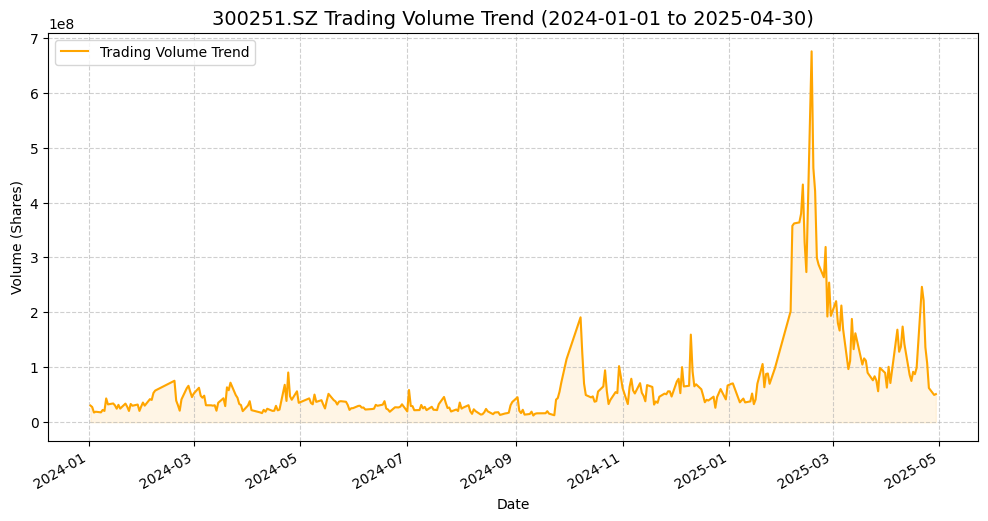

In [11]:
# 测试运行
target_stock = "300251.SZ" 
start = "2024-01-01"
end = "2025-04-30"

volumes = get_stock_volume_line(target_stock, start, end)

正在获取 NVDA 的交易量趋势数据...


[*********************100%***********************]  1 of 1 completed


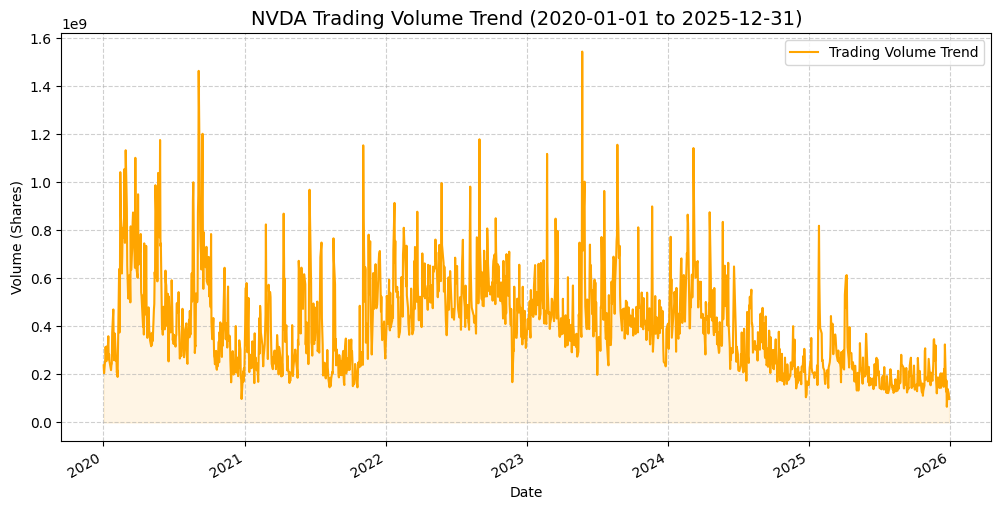

In [12]:
nvidia = get_stock_volume_line("NVDA", "2020-01-01", "2025-12-31")   #英伟达

正在获取 SNDK 的交易量趋势数据...


[*********************100%***********************]  1 of 1 completed


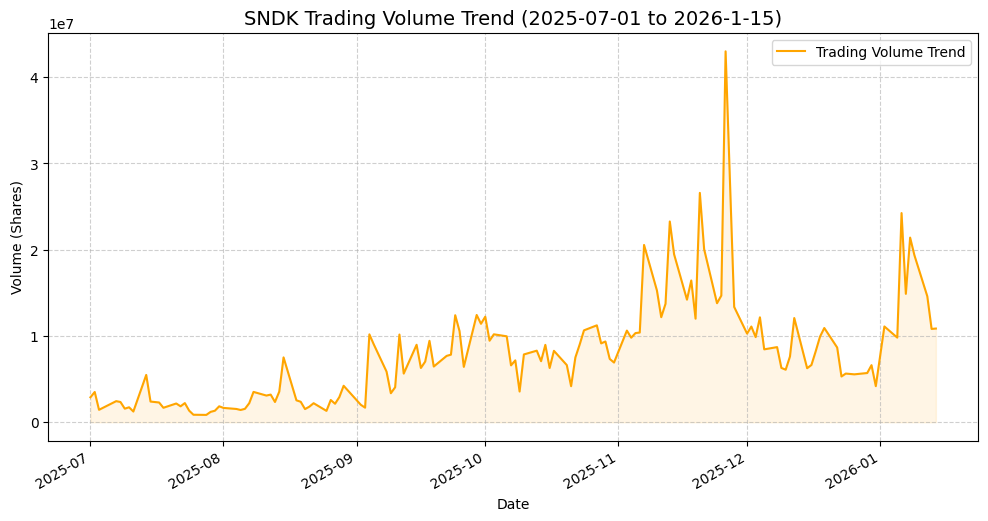

In [13]:
sandisk_data = get_stock_volume_line("SNDK", "2025-07-01", "2026-1-15")  #闪迪